# EmotionCLIP-ReID JupyterHub Runbook

Notebook này chuẩn bị dữ liệu FER2013 7 lớp từ Hugging Face, tạo manifest đúng format repo, chạy train theo YAML, và infer một ảnh mẫu. `RUN_FULL` chỉ điều khiển phần chuẩn bị dữ liệu; epoch, batch, log, checkpoint và output train nằm trong file config YAML.

Lưu ý hiện tại: model trong repo train nhánh cảm xúc chính. `au_labels` trong manifest đã được loader giữ lại làm metadata, nhưng loss/model hiện chưa backprop nhánh AU thật. Cell AU cuối notebook là scaffold giải thích/pseudo-evidence để chuẩn bị nối DISFA/RAF-AU/OpenFace sau.

## 0. Kernel khuyến nghị

Chọn kernel **Python 3.10** có **PyTorch CUDA**. Repo đang dùng `environment_emotionclip_cuda.yml` với `python=3.10` và `pytorch-cuda=12.1`; CUDA 12.1 wheel vẫn chạy được trên driver mới hơn như CUDA 13.0. Nếu JupyterHub chỉ có kernel Python 3.9 thì vẫn có thể thử, nhưng Python 3.10 là đường ít lỗi nhất.

In [1]:
# Chạy cell này trong đúng kernel bạn định train.
# Cell này cài package vào CHÍNH Python của kernel qua sys.executable.
import importlib
import importlib.util
import os
import site
import subprocess
import sys

INSTALL_TORCH = True
TORCH_INDEX_URL = 'https://download.pytorch.org/whl/cu121'

print('Python executable:', sys.executable)
print('Python version:', sys.version)
print('User site enabled:', site.ENABLE_USER_SITE)
print('User site:', site.getusersitepackages())
print('PYTHONNOUSERSITE:', os.environ.get('PYTHONNOUSERSITE'))

base_packages = [
    'numpy',
    'pillow',
    'pyyaml',
    'tqdm',
    'datasets',
    'ftfy',
    'regex',
    'matplotlib',
]
print('Installing/checking base packages into kernel Python...')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', '--upgrade', *base_packages])

if INSTALL_TORCH:
    try:
        import torch
        print('torch already installed:', torch.__version__)
    except ModuleNotFoundError:
        print('Torch missing. Installing PyTorch CUDA 12.1 wheel into this kernel...')
        subprocess.check_call([
            sys.executable,
            '-m',
            'pip',
            'install',
            '--user',
            '--upgrade',
            '--no-cache-dir',
            'torch',
            'torchvision',
            'torchaudio',
            '--index-url',
            TORCH_INDEX_URL,
        ])
        importlib.invalidate_caches()

try:
    import torch
except ModuleNotFoundError as exc:
    print('Torch vẫn chưa import được trong kernel này.')
    print('pip show torch:')
    subprocess.run([sys.executable, '-m', 'pip', 'show', 'torch'], check=False)
    print('find_spec(torch):', importlib.util.find_spec('torch'))
    print('sys.path:')
    for item in sys.path:
        print('  ', item)
    print('Hãy restart kernel. Nếu vẫn lỗi, chạy thủ công:')
    print(f'{sys.executable} -m pip install --user --upgrade --no-cache-dir torch torchvision torchaudio --index-url {TORCH_INDEX_URL}')
    raise

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('gpu:', torch.cuda.get_device_name(0))


Python executable: /opt/tljh/user/envs/py310/bin/python
Python version: 3.10.19 | packaged by conda-forge | (main, Jan 26 2026, 23:45:08) [GCC 14.3.0]
User site enabled: True
User site: /home/jupyter-hault/.local/lib/python3.10/site-packages
PYTHONNOUSERSITE: None
Installing/checking base packages into kernel Python...
torch already installed: 2.5.1+cu121
torch: 2.5.1+cu121
cuda available: True
gpu: Tesla T4


## 0.1. Clone hoặc pull source repo trên JupyterHub

Chạy cell này nếu source code chưa có trên JupyterHub hoặc bạn muốn cập nhật code mới. Nếu server chưa cấu hình SSH key GitHub, đổi `GIT_REPO_URL` sang HTTPS URL của repo.

In [2]:
from pathlib import Path
import os
import subprocess

JUPYTER_WORKSPACE = Path('/home/jupyter-hault')
REPO_DIR = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'
# GIT_REPO_URL = 'git@github.com:haulth/EmotionCLIP-ReID.git'
# Nếu SSH GitHub chưa sẵn sàng trên server, đổi thành HTTPS, ví dụ:
GIT_REPO_URL = 'https://github.com/haulth/EmotionCLIP-ReID.git'

JUPYTER_WORKSPACE.mkdir(parents=True, exist_ok=True)
if (REPO_DIR / ".git").exists():
    print('Repo đã tồn tại, pull code mới:', REPO_DIR)
    result = subprocess.run([
        'git', '-C', str(REPO_DIR), 'pull', '--ff-only'
    ], text=True, capture_output=True)
else:
    print('Repo chưa tồn tại, clone vào:', REPO_DIR)
    result = subprocess.run([
        'git', 'clone', GIT_REPO_URL, str(REPO_DIR)
    ], text=True, capture_output=True)

print(result.stdout)

os.chdir(REPO_DIR)
REPO_OVERRIDE = REPO_DIR
print('Repo:', Path.cwd())
print('Has train_emotionclip.py:', (Path.cwd() / 'train_emotionclip.py').exists())
print('Has downloader:', (Path.cwd() / 'tools/download_hf_emotion_dataset.py').exists())


Repo đã tồn tại, pull code mới: /home/jupyter-hault/EmotionCLIP-ReID
Already up to date.

Repo: /home/jupyter-hault/EmotionCLIP-ReID
Has train_emotionclip.py: True
Has downloader: True


In [3]:
from pathlib import Path
import os

# Nếu auto-detect không thấy repo, điền đường dẫn repo của bạn vào đây, ví dụ:
# Work path JupyterHub của bạn:
JUPYTER_WORKSPACE = Path('/home/jupyter-hault')
REPO_OVERRIDE = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'

def find_repo_root(start: Path) -> Path:
    if REPO_OVERRIDE is not None:
        repo = Path(REPO_OVERRIDE).expanduser().resolve()
        if (repo / 'train_emotionclip.py').exists() and (repo / 'tools').exists():
            return repo
        raise FileNotFoundError(f'REPO_OVERRIDE không đúng: {repo}')

    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'train_emotionclip.py').exists() and (candidate / 'tools').exists():
            return candidate

    search_roots = [Path.home(), Path('/home'), Path('/mnt/e/Source')]
    seen = set()
    for root in search_roots:
        try:
            root = root.resolve()
        except FileNotFoundError:
            continue
        if root in seen or not root.exists():
            continue
        seen.add(root)
        try:
            for marker in root.rglob('train_emotionclip.py'):
                candidate = marker.parent
                if (candidate / 'tools/download_hf_emotion_dataset.py').exists():
                    return candidate
        except PermissionError:
            continue

    raise FileNotFoundError(
        'Không tìm thấy repo root chứa train_emotionclip.py. '
        'Hãy set REPO_OVERRIDE ở cell này thành đường dẫn thư mục EmotionCLIP-ReID.'
    )

REPO = find_repo_root(Path.cwd())
os.chdir(REPO)
print('Repo:', REPO)
print('Current working directory:', Path.cwd())
print('Has train_emotionclip.py:', (REPO / 'train_emotionclip.py').exists())
print('Has downloader:', (REPO / 'tools/download_hf_emotion_dataset.py').exists())


Repo: /home/jupyter-hault/EmotionCLIP-ReID
Current working directory: /home/jupyter-hault/EmotionCLIP-ReID
Has train_emotionclip.py: True
Has downloader: True


## 1. Kiểm tra/cài package tối thiểu

Nếu JupyterHub đã có environment `emotionclip`, cell này chỉ kiểm tra. Nếu thiếu package nhẹ cho data export, nó sẽ cài qua `pip` trong kernel hiện tại. PyTorch/CUDA nên được cài bằng conda theo `environment_emotionclip_cuda.yml` trên server của bạn.

In [4]:
import importlib.util
import subprocess
import sys

for pkg in ['datasets', 'PIL', 'yaml', 'tqdm', 'ftfy', 'regex']:
    print(pkg, 'OK' if importlib.util.find_spec(pkg) else 'MISSING')

missing = []
if importlib.util.find_spec('datasets') is None:
    missing.append('datasets')
if importlib.util.find_spec('PIL') is None:
    missing.append('pillow')
if importlib.util.find_spec('tqdm') is None:
    missing.append('tqdm')
if importlib.util.find_spec('ftfy') is None:
    missing.append('ftfy')
if importlib.util.find_spec('regex') is None:
    missing.append('regex')

if missing:
    print('Installing:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

try:
    import torch
    print('torch:', torch.__version__, 'cuda:', torch.cuda.is_available())
except Exception as exc:
    print('Torch is not ready in this kernel:', exc)

datasets OK
PIL OK
yaml OK
tqdm OK
ftfy OK
regex OK
torch: 2.5.1+cu121 cuda: True


## 1.1. Logic training hiện tại

**Dataset đang dùng:** FER2013 từ Hugging Face `Aaryan333/fer2013_train_publicTest_privateTest`. Đây là bài toán nhận diện cảm xúc 7 lớp từ ảnh mặt 48x48.

**Label gốc FER2013:** `Angry`, `Disgust`, `Fear`, `Happy`, `Sad`, `Surprise`, `Neutral`. Trong repo, label được chuẩn hóa về thứ tự canonical:

| emotion_id | emotion | FER2013 label |
|---:|---|---|
| 0 | anger | Angry |
| 1 | disgust | Disgust |
| 2 | fear | Fear |
| 3 | happiness | Happy |
| 4 | sadness | Sad |
| 5 | surprise | Surprise |
| 6 | neutral | Neutral |

**Manifest sau khi convert:** mỗi dòng có `image_path`, `emotion`, `emotion_id`, `split`, `source`. Ví dụ: `{"image_path":"train/happiness/train_000001.jpg","emotion":"happiness","emotion_id":3,"split":"train"}`.

**Model đang train:** nhánh emotion chính của `EmotionCLIPModel`. Stage 1 học prompt/text descriptor cho 7 class emotion. Stage 2 fine-tune image encoder/adapter/classifier với loss gồm classification, image-text alignment và evidential uncertainty.

**Đầu ra inference:** model trả về `probabilities` cho 7 emotion, `emotion_id` dự đoán, `emotion` dự đoán, `descriptor_similarity` giữa ảnh và từng text descriptor, và `uncertainty`. Nhánh AU hiện tại mới là scaffold/explanation, chưa tham gia loss train thật.

In [5]:
CANONICAL_EMOTIONS = ('anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral')
FER2013_LABELS = ('Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral')
label_rows = [{'emotion_id': i, 'emotion': e, 'fer2013_label': f} for i, (e, f) in enumerate(zip(CANONICAL_EMOTIONS, FER2013_LABELS))]
label_rows


[{'emotion_id': 0, 'emotion': 'anger', 'fer2013_label': 'Angry'},
 {'emotion_id': 1, 'emotion': 'disgust', 'fer2013_label': 'Disgust'},
 {'emotion_id': 2, 'emotion': 'fear', 'fer2013_label': 'Fear'},
 {'emotion_id': 3, 'emotion': 'happiness', 'fer2013_label': 'Happy'},
 {'emotion_id': 4, 'emotion': 'sadness', 'fer2013_label': 'Sad'},
 {'emotion_id': 5, 'emotion': 'surprise', 'fer2013_label': 'Surprise'},
 {'emotion_id': 6, 'emotion': 'neutral', 'fer2013_label': 'Neutral'}]

## 2. Tải dataset và tạo manifest

Dataset mặc định: `Aaryan333/fer2013_train_publicTest_privateTest`. Nó có 7 cảm xúc cơ bản theo thứ tự tương thích repo: anger, disgust, fear, happiness, sadness, surprise, neutral.

In [6]:
RUN_FULL = True  
DATASET_ID = 'Aaryan333/fer2013_train_publicTest_privateTest'

# Data sẽ được ghi vào đúng working directory hiện tại của kernel.
# Nếu cell Repo tìm được repo thì Path.cwd() là repo root.
# Nếu không có repo trên JupyterHub, Path.cwd() là workspace hiện tại của kernel.
KERNEL_WORKSPACE = Path.cwd().resolve()

if RUN_FULL:
    DATA_ROOT = KERNEL_WORKSPACE / 'data/hf_fer2013'
    MAX_SAMPLES = -1
else:
    DATA_ROOT = KERNEL_WORKSPACE / 'data/hf_fer2013_smoke'
    MAX_SAMPLES = 200

MANIFEST = DATA_ROOT / 'manifest.jsonl'
IMAGES_ROOT = DATA_ROOT / 'images'
print('KERNEL_WORKSPACE:', KERNEL_WORKSPACE)
print('DATA_ROOT:', DATA_ROOT)
print('MANIFEST:', MANIFEST)
print('IMAGES_ROOT:', IMAGES_ROOT)
print('MAX_SAMPLES per HF split:', MAX_SAMPLES)


KERNEL_WORKSPACE: /home/jupyter-hault/EmotionCLIP-ReID
DATA_ROOT: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013
MANIFEST: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest.jsonl
IMAGES_ROOT: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images
MAX_SAMPLES per HF split: -1


In [7]:
import json
import os
import subprocess
import sys
from collections import Counter
from pathlib import Path

# Cell này tải data TRÊN SERVER JUPYTERHUB.
# Nếu data đã tồn tại thì bỏ qua tải lại. Đặt FORCE_DOWNLOAD = True để tải/ghi lại.
FORCE_DOWNLOAD = False

try:
    REPO
except NameError:
    REPO = None

if REPO is not None:
    try:
        os.chdir(REPO)
    except Exception:
        pass

DATA_ROOT = Path(DATA_ROOT).expanduser().resolve()
MANIFEST = DATA_ROOT / 'manifest.jsonl'
IMAGES_ROOT = DATA_ROOT / 'images'
print('Kernel cwd before download:', Path.cwd().resolve())
print('DATA_ROOT absolute:', DATA_ROOT)
print('MANIFEST absolute:', MANIFEST)
print('IMAGES_ROOT absolute:', IMAGES_ROOT)

records = []
if MANIFEST.exists() and IMAGES_ROOT.exists() and not FORCE_DOWNLOAD:
    print('Data đã tồn tại, bỏ qua tải lại.')
    with MANIFEST.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    print('num records:', len(records))
    print('splits:', Counter(r['split'] for r in records))
    print('classes:', Counter(r['emotion'] for r in records))
else:
    download_script = Path('tools/download_hf_emotion_dataset.py')
    if download_script.exists():
        cmd = [
            sys.executable,
            str(download_script),
            '--dataset', DATASET_ID,
            '--output-root', str(DATA_ROOT),
            '--max-samples-per-split', str(MAX_SAMPLES),
            '--test-as', 'val',
        ]
        print('Running repo downloader:', ' '.join(cmd))
        result = subprocess.run(cmd, text=True, capture_output=True)
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            raise subprocess.CalledProcessError(result.returncode, cmd)

        with MANIFEST.open('r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))
        print('num records:', len(records))
        print('splits:', Counter(r['split'] for r in records))
        print('classes:', Counter(r['emotion'] for r in records))
    else:
        print('Không thấy repo downloader, tải data trực tiếp trong notebook trên server JupyterHub.')
        print('cwd:', Path.cwd())
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--user', '-q', 'datasets', 'pillow', 'tqdm'])

        from datasets import load_dataset

        CANONICAL_EMOTIONS = ('anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral')
        EMOTION_TO_ID = {name: idx for idx, name in enumerate(CANONICAL_EMOTIONS)}
        ALIASES = {
            'angry': 'anger', 'anger': 'anger',
            'disgust': 'disgust', 'disgusted': 'disgust',
            'fear': 'fear', 'fearful': 'fear',
            'happy': 'happiness', 'happiness': 'happiness',
            'sad': 'sadness', 'sadness': 'sadness',
            'surprise': 'surprise', 'surprised': 'surprise',
            'neutral': 'neutral',
        }

        def split_name(name):
            name = str(name).lower()
            if name in {'train', 'training'}:
                return 'train'
            if name in {'validation', 'valid', 'val', 'publictest'}:
                return 'val'
            if name in {'test', 'privatetest'}:
                return 'val'
            return name

        def normalize_label(value, label_feature=None):
            if label_feature is not None and hasattr(label_feature, 'int2str'):
                try:
                    value = label_feature.int2str(int(value))
                except Exception:
                    pass
            text = str(value).strip().lower().replace('-', '_').replace(' ', '_')
            if text.isdigit():
                return CANONICAL_EMOTIONS[int(text)]
            return ALIASES[text]

        DATA_ROOT.mkdir(parents=True, exist_ok=True)
        ds = load_dataset(DATASET_ID, streaming=True)
        counts = {}
        for hf_split, split_data in ds.items():
            split = split_name(hf_split)
            try:
                split_data = split_data.shuffle(seed=1234, buffer_size=10000)
            except Exception:
                pass
            label_feature = getattr(split_data, 'features', {}).get('label')
            for idx, sample in enumerate(split_data):
                if MAX_SAMPLES is not None and int(MAX_SAMPLES) >= 0 and idx >= int(MAX_SAMPLES):
                    break
                emotion = normalize_label(sample['label'], label_feature)
                rel_path = Path(split) / emotion / f'{hf_split}_{idx:06d}.jpg'
                out_path = IMAGES_ROOT / rel_path
                out_path.parent.mkdir(parents=True, exist_ok=True)
                sample['image'].convert('RGB').save(out_path)
                records.append({
                    'image_path': rel_path.as_posix(),
                    'emotion': emotion,
                    'emotion_id': EMOTION_TO_ID[emotion],
                    'split': split,
                    'source': DATASET_ID,
                    'hf_split': hf_split,
                    'hf_index': idx,
                })
                counts[split] = counts.get(split, 0) + 1

        with MANIFEST.open('w', encoding='utf-8') as f:
            for record in records:
                f.write(json.dumps(record, ensure_ascii=False) + '\n')

        print(f'Wrote {len(records)} records to {MANIFEST}')
        print(f'Images root: {IMAGES_ROOT}')
        print(f'Split counts: {counts}')
        print('classes:', Counter(r['emotion'] for r in records))


Kernel cwd before download: /home/jupyter-hault/EmotionCLIP-ReID
DATA_ROOT absolute: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013
MANIFEST absolute: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest.jsonl
IMAGES_ROOT absolute: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images
Data đã tồn tại, bỏ qua tải lại.
num records: 35887
splits: Counter({'train': 28709, 'val': 7178})
classes: Counter({'happiness': 8989, 'neutral': 6198, 'sadness': 6077, 'fear': 5121, 'anger': 4953, 'surprise': 4002, 'disgust': 547})


In [8]:
import json
from collections import Counter

records = []
with MANIFEST.open('r', encoding='utf-8') as handle:
    for line in handle:
        records.append(json.loads(line))

print('num records:', len(records))
print('splits:', Counter(r['split'] for r in records))
print('classes:', Counter(r['emotion'] for r in records))
print('first record:', records[0])

num records: 35887
splits: Counter({'train': 28709, 'val': 7178})
classes: Counter({'happiness': 8989, 'neutral': 6198, 'sadness': 6077, 'fear': 5121, 'anger': 4953, 'surprise': 4002, 'disgust': 547})
first record: {'image_path': 'train/neutral/train_000000.jpg', 'emotion': 'neutral', 'emotion_id': 6, 'split': 'train', 'source': 'Aaryan333/fer2013_train_publicTest_privateTest', 'hf_split': 'train', 'hf_index': 0}


## 2.1. Visualize dataset

Cell dưới vẽ phân bố class/split và hiển thị một grid ảnh mẫu để kiểm tra data đã tải đúng, path ảnh đọc được, và nhãn cảm xúc nhìn hợp lý.

Total records: 35887
Splits: Counter({'train': 28709, 'val': 7178})
Classes: Counter({'happiness': 8989, 'neutral': 6198, 'sadness': 6077, 'fear': 5121, 'anger': 4953, 'surprise': 4002, 'disgust': 547})


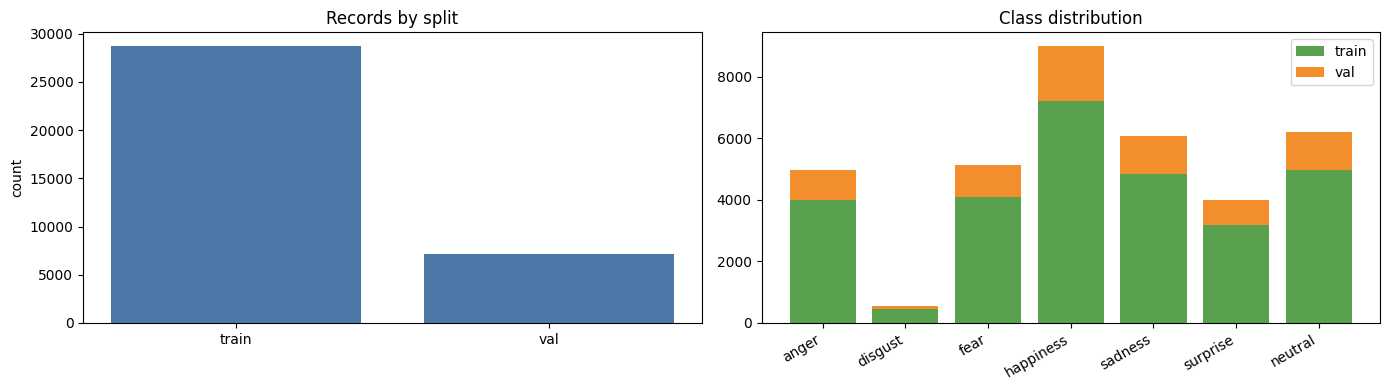

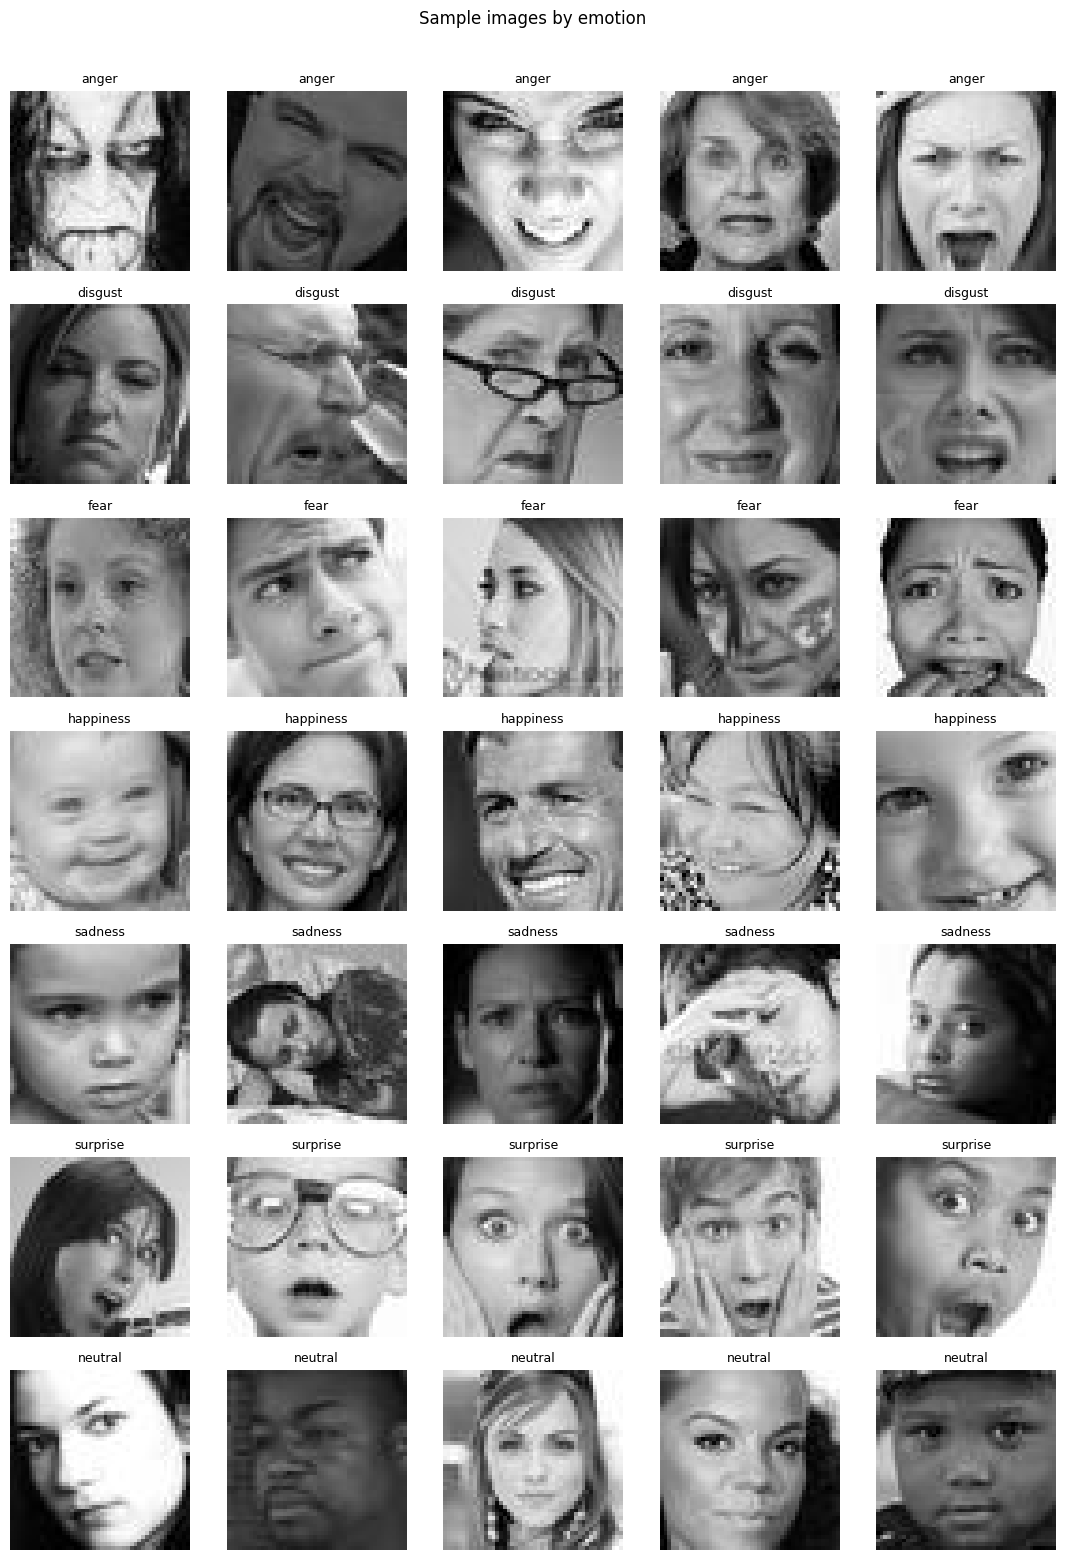

In [9]:
from collections import Counter, defaultdict
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

assert records, 'records rỗng. Hãy chạy cell download/load manifest trước.'
split_counts = Counter(r['split'] for r in records)
class_counts = Counter(r['emotion'] for r in records)
split_class_counts = defaultdict(Counter)
for r in records:
    split_class_counts[r['split']][r['emotion']] += 1

print('Total records:', len(records))
print('Splits:', split_counts)
print('Classes:', class_counts)

classes = ['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise', 'neutral']
splits = sorted(split_counts.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(split_counts.keys(), split_counts.values(), color='#4C78A8')
axes[0].set_title('Records by split')
axes[0].set_ylabel('count')

x = range(len(classes))
bottom = [0] * len(classes)
colors = {'train': '#59A14F', 'val': '#F28E2B', 'test': '#E15759'}
for split in splits:
    values = [split_class_counts[split][c] for c in classes]
    axes[1].bar(x, values, bottom=bottom, label=split, color=colors.get(split))
    bottom = [b + v for b, v in zip(bottom, values)]
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(classes, rotation=30, ha='right')
axes[1].set_title('Class distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

# Grid ảnh mẫu: mỗi class tối đa 5 ảnh train, nếu thiếu thì lấy toàn bộ split.
samples_by_class = defaultdict(list)
for r in records:
    if r['split'] == 'train':
        samples_by_class[r['emotion']].append(r)
for c in classes:
    if not samples_by_class[c]:
        samples_by_class[c] = [r for r in records if r['emotion'] == c]

cols = 5
rows = len(classes)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
for row_idx, c in enumerate(classes):
    choices = samples_by_class[c][:cols]
    if len(choices) > cols:
        choices = random.sample(choices, cols)
    for col_idx in range(cols):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        if col_idx < len(choices):
            img_path = Path(IMAGES_ROOT) / choices[col_idx]['image_path']
            try:
                ax.imshow(Image.open(img_path).convert('RGB'))
                ax.set_title(c, fontsize=9)
            except Exception as exc:
                ax.text(0.5, 0.5, f'read error\n{img_path.name}', ha='center', va='center', fontsize=8)
                print('Image read error:', img_path, exc)
        elif col_idx == 0:
            ax.text(0.5, 0.5, f'no {c}', ha='center', va='center')
fig.suptitle('Sample images by emotion', y=1.01)
plt.tight_layout()
plt.show()


## 3. Preview ảnh mẫu

{'image_path': 'train/neutral/train_000000.jpg', 'emotion': 'neutral', 'emotion_id': 6, 'split': 'train', 'source': 'Aaryan333/fer2013_train_publicTest_privateTest', 'hf_split': 'train', 'hf_index': 0}
/home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images/train/neutral/train_000000.jpg


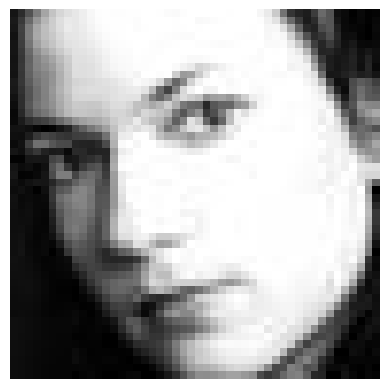

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

sample = records[0]
img_path = IMAGES_ROOT / sample['image_path']
print(sample)
print(img_path)
plt.imshow(Image.open(img_path))
plt.axis('off');

## 4. Training EmotionCLIP-ReID

Phần này chạy training bằng đúng kernel hiện tại và lấy cấu hình nền từ `CONFIG_FILE`. Có thể chỉnh trực tiếp `STAGE1_EPOCHS`, `STAGE2_EPOCHS` và `RELIABILITY_WARMUP_EPOCHS` trong cell kế tiếp; notebook sẽ truyền các giá trị này qua CLI override mà không sửa YAML.

In [11]:
from pathlib import Path
import os
import yaml

JUPYTER_WORKSPACE = Path('/home/jupyter-hault')
REPO_DIR = JUPYTER_WORKSPACE / 'EmotionCLIP-ReID'
CONFIG_FILE = 'configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml'
CONFIG_PATH = REPO_DIR / CONFIG_FILE

def repo_path(value):
    path = Path(value)
    return path if path.is_absolute() else REPO_DIR / path

with CONFIG_PATH.open('r', encoding='utf-8') as handle:
    TRAIN_CFG = yaml.safe_load(handle) or {}

DATASET_CFG = TRAIN_CFG['DATASETS']
SOLVER_CFG = TRAIN_CFG['SOLVER']

# ===== Điều chỉnh epoch training tại đây =====
STAGE1_EPOCHS = 200
STAGE2_EPOCHS = 200
RELIABILITY_WARMUP_EPOCHS = min(10, STAGE2_EPOCHS)
assert STAGE1_EPOCHS >= 1 and STAGE2_EPOCHS >= 1
assert 1 <= RELIABILITY_WARMUP_EPOCHS <= STAGE2_EPOCHS
MANIFEST = repo_path(DATASET_CFG['MANIFEST']).resolve()
IMAGES_ROOT = repo_path(DATASET_CFG['ROOT_DIR']).resolve()
CONFIGURED_OUTPUT_ROOT = repo_path(TRAIN_CFG['OUTPUT_DIR']).resolve()
OUTPUT_ROOT = CONFIGURED_OUTPUT_ROOT.parent / f'emotionclip_hf_fer2013_s1-{STAGE1_EPOCHS}_s2-{STAGE2_EPOCHS}'
RUN_ID = 'fer2013-seed1234'  # đổi cho mỗi run; không tái sử dụng
OUTPUT_DIR = str(OUTPUT_ROOT / RUN_ID)

print('config:', CONFIG_FILE)
print('manifest:', MANIFEST)
print('images:', IMAGES_ROOT)
print('output:', OUTPUT_DIR)
print('stage1 epochs/batch/log:', STAGE1_EPOCHS, SOLVER_CFG['STAGE1']['IMS_PER_BATCH'], SOLVER_CFG['STAGE1'].get('LOG_PERIOD'))
print('stage2 epochs/batch/log:', STAGE2_EPOCHS, SOLVER_CFG['STAGE2']['IMS_PER_BATCH'], SOLVER_CFG['STAGE2'].get('LOG_PERIOD'))
print('reliability warmup epochs:', RELIABILITY_WARMUP_EPOCHS)
print('cwd:', REPO_DIR)
assert (REPO_DIR / 'train_emotionclip.py').exists(), 'Không thấy train_emotionclip.py. Hãy clone/pull hoặc unzip source repo trước.'
assert CONFIG_PATH.exists(), f'Không thấy config: {CONFIG_PATH}'
assert MANIFEST.exists(), f'Không thấy manifest: {MANIFEST}. Hãy chạy cell download data trước.'
assert IMAGES_ROOT.exists(), f'Không thấy images root: {IMAGES_ROOT}'


config: configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml
manifest: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/manifest.jsonl
images: /home/jupyter-hault/EmotionCLIP-ReID/data/hf_fer2013/images
output: /home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_hf_fer2013_200epoch
stage1 epochs/batch/log: 200 128 0
stage2 epochs/batch/log: 200 64 0
cwd: /home/jupyter-hault/EmotionCLIP-ReID


In [ ]:
import os
import subprocess
import sys
from utils.notebook_progress import stream_process_output

GPU_ID = 0  # doi sang 1 neu muon dung GPU thu hai

train_cmd = [
    sys.executable,
    '-u',  # unbuffered: log training hiện realtime hơn
    'train_emotionclip.py',
    '--gpu', str(GPU_ID),
    '--run-id', RUN_ID,
    '--config_file', CONFIG_FILE,
    'SOLVER.STAGE1.MAX_EPOCHS', str(STAGE1_EPOCHS),
    'SOLVER.STAGE2.MAX_EPOCHS', str(STAGE2_EPOCHS),
    'SOLVER.STAGE2.RELIABILITY_WARMUP_EPOCHS', str(RELIABILITY_WARMUP_EPOCHS),
    'OUTPUT_DIR', str(OUTPUT_ROOT),
]

env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'
env['EMOTIONCLIP_PROGRESS'] = '1'
print('Running train command:')
print(' '.join(train_cmd))
print('--- training log start ---')

process = subprocess.Popen(
    train_cmd,
    cwd=REPO_DIR,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

try:
    log_chunks = stream_process_output(process)
finally:
    return_code = process.wait()

print('--- training log end ---')
if return_code != 0:
    log_lines = ''.join(log_chunks).splitlines(True)
    tail = ''.join(log_lines[-80:])
    print('Training failed. Last 80 log lines:')
    print(tail)
    raise subprocess.CalledProcessError(return_code, train_cmd)
print('Training finished.')


Running train command:
/opt/tljh/user/envs/py310/bin/python -u train_emotionclip.py --gpu 0 --config_file configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml
--- training log start ---


2026-07-15 11:15:13,351 emotionclip.train INFO: CUDA device selected device=cuda:0 name=Tesla T4 visible_devices=2
2026-07-15 11:15:13,352 emotionclip.train INFO: Train config saved path=outputs/emotionclip_hf_fer2013_200epoch/train_config_20260715_111513.csv
2026-07-15 11:15:13,352 emotionclip.train INFO: Run config config_file=configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml device=cuda:0 model=ViT-B-16 manifest=data/hf_fer2013/manifest.jsonl root_dir=data/hf_fer2013/images output_dir=outputs/emotionclip_hf_fer2013_200epoch size_train=[224, 224] size_test=[224, 224] run_stage1=True run_stage2=True progress_bar=auto
2026-07-15 11:15:13,352 emotionclip.train INFO: Model config n_ctx=4 adapter_dim=64 topk_patches=5 train_last_blocks=1 classifier_weight=1.0000 global_weight=1.0000 local_weight=0.5000
2026-07-15 11:15:13,352 emotionclip.train INFO: Solver config seed=1234 stage1_epochs=200 stage1_batch=128 stage1_lr=0.0003 stage1_log_period=0 stage2_epochs=200 stage2_batch=64 stag

In [ ]:
from pathlib import Path
from utils.notebook_metrics import load_validation_metrics, print_validation_summary

validation_metrics = load_validation_metrics(
    candidate_output_dirs=[
        OUTPUT_DIR,
    ],
    csv_candidates=[
        Path(OUTPUT_DIR) / "validation_metrics.csv",
    ],
    summary_candidates=[
        Path(OUTPUT_DIR) / "best_metrics_summary.json",
    ],
    uncertainty_candidates=[
        Path(OUTPUT_DIR) / "uncertainty_summary.json",
    ],
)

RESULT_DIR = validation_metrics["result_dir"]
metric_files = validation_metrics["metric_files"]
metric_history = validation_metrics["metric_history"]
metrics_by_epoch = validation_metrics["metrics_by_epoch"]
metrics_latest = validation_metrics["metrics_latest"]
metrics_best = validation_metrics["metrics_best"]
best_metric = validation_metrics["best_metric"]

print("OUTPUT_DIR:", Path(OUTPUT_DIR))
print("RESULT_DIR:", RESULT_DIR)
print("best checkpoint exists:", (Path(OUTPUT_DIR) / "best_emotionclip.pth").exists())
print("checkpoints:")
for checkpoint in sorted(Path(OUTPUT_DIR).glob("*.pth")):
    print(" ", checkpoint.name, f"{checkpoint.stat().st_size / (1024 * 1024):.1f} MB")
print_validation_summary(validation_metrics)

### 4.2 Biểu đồ metric validation theo epoch

In [ ]:
from utils.notebook_metrics import plot_validation_metric_curves

plot_validation_metric_curves(validation_metrics, dataset_name="FER2013", file_prefix="fer2013")

### 4.3 Biểu đồ loss/accuracy training từ log

In [ ]:
from utils.notebook_metrics import load_training_history, plot_training_metric_curves, unique_paths

training_candidate_dirs = unique_paths(
    RESULT_DIR,
    OUTPUT_DIR,
    REPO / "outputs" / "emotionclip_hf_fer2013_full",
    REPO / "outputs" / "emotionclip_hf_fer2013_smoke",
    REPO / "outputs" / "fer2013",
)
training_history, training_source = load_training_history(
    training_candidate_dirs,
    csv_candidates=[
        RESULT_DIR / "training_epoch_losses.csv",
        Path(OUTPUT_DIR) / "training_epoch_losses.csv",
        REPO / "outputs" / "fer2013" / "training_epoch_losses.csv",
    ],
)
plot_training_metric_curves(training_history, training_source, RESULT_DIR, file_prefix="fer2013")

### 4.4 Confusion matrix và per-class F1

In [ ]:
from utils.notebook_metrics import plot_confusion_matrix_and_f1

plot_confusion_matrix_and_f1(validation_metrics, dataset_name="FER2013", file_prefix="fer2013")

## 5. Xem metrics và infer một ảnh

In [ ]:
from pathlib import Path
from utils.notebook_metrics import (
    load_validation_metrics,
    plot_confusion_matrix_and_f1,
    plot_validation_metric_curves,
    print_validation_summary,
)

current_output = Path(OUTPUT_DIR)
is_rafdb_output = "raf" in current_output.as_posix().lower()
active_dataset_name = "RAF-DB" if is_rafdb_output else "FER2013"
active_file_prefix = "rafdb" if is_rafdb_output else "fer2013"

if is_rafdb_output:
    candidate_output_dirs = [
        current_output,
    ]
    csv_candidates = []
    summary_candidates = []
    uncertainty_candidates = []
else:
    candidate_output_dirs = [
        current_output,
    ]
    csv_candidates = [
        current_output / "validation_metrics.csv",
    ]
    summary_candidates = [
        current_output / "best_metrics_summary.json",
    ]
    uncertainty_candidates = [
        current_output / "uncertainty_summary.json",
    ]

validation_metrics = load_validation_metrics(
    candidate_output_dirs=candidate_output_dirs,
    csv_candidates=csv_candidates,
    summary_candidates=summary_candidates,
    uncertainty_candidates=uncertainty_candidates,
)
RESULT_DIR = validation_metrics["result_dir"]
metric_files = validation_metrics["metric_files"]
metric_history = validation_metrics["metric_history"]
metrics_by_epoch = validation_metrics["metrics_by_epoch"]
metrics_latest = validation_metrics["metrics_latest"]
metrics_best = validation_metrics["metrics_best"]
best_metric = validation_metrics["best_metric"]

print_validation_summary(validation_metrics)
plot_validation_metric_curves(validation_metrics, dataset_name=active_dataset_name, file_prefix=active_file_prefix)
plot_confusion_matrix_and_f1(validation_metrics, dataset_name=active_dataset_name, file_prefix=active_file_prefix)

In [ ]:
val_records = [r for r in records if r['split'] == 'val']
infer_record = val_records[0] if val_records else records[0]
infer_image = IMAGES_ROOT / infer_record['image_path']
print('ground truth:', infer_record)
print('image:', infer_image)

subprocess.check_call([
    sys.executable,
    'infer_emotionclip.py',
    '--config_file', 'configs/emotion/vit_b16_emotionclip_hf_fer2013_quick.yml',
    '--weight', str(Path(OUTPUT_DIR) / 'best_emotionclip.pth'),
    '--image', str(infer_image),
])

## 5.2. Visual kết quả từng bước

Cell dưới trực quan hóa pipeline trên một vài ảnh validation: ảnh gốc → ảnh sau transform 224x224 → ground truth/prediction → biểu đồ xác suất 7 emotion → descriptor similarity → uncertainty. Chạy sau khi đã có `best_emotionclip.pth` trong `OUTPUT_DIR`.

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
import torch

from config.emotion_defaults import load_emotion_cfg
from datasets.emotion_manifest import CANONICAL_EMOTIONS, FaceSafeTransform
from model.emotionclip_model import EmotionCLIPModel
from processor.processor_emotionclip import load_emotion_checkpoint

ckpt_path = Path(OUTPUT_DIR) / 'best_emotionclip.pth'
assert ckpt_path.exists(), f'Không thấy checkpoint: {ckpt_path}. Hãy chạy training trước.'
val_records = [r for r in records if r['split'] == 'val']
assert val_records, 'Không có val records để visualize.'
N_VIS = min(6, len(val_records))
vis_records = random.sample(val_records, N_VIS)

cfg = load_emotion_cfg(CONFIG_FILE, [])
if cfg['MODEL']['DEVICE'] == 'cuda' and not torch.cuda.is_available():
    cfg['MODEL']['DEVICE'] = 'cpu'
device = torch.device(cfg['MODEL']['DEVICE'])
model_cfg = cfg['MODEL']['EMOTION']
model = EmotionCLIPModel(
    class_names=CANONICAL_EMOTIONS,
    backbone_name=cfg['MODEL']['NAME'],
    image_size=cfg['INPUT']['SIZE_TEST'],
    stride_size=cfg['MODEL']['STRIDE_SIZE'],
    n_ctx=int(model_cfg['N_CTX']),
    adapter_dim=int(model_cfg['ADAPTER_DIM']),
    adapter_dropout=float(model_cfg['ADAPTER_DROPOUT']),
    topk_patches=int(model_cfg['TOPK_PATCHES']),
    global_weight=float(model_cfg['GLOBAL_WEIGHT']),
    local_weight=float(model_cfg['LOCAL_WEIGHT']),
    classifier_weight=float(model_cfg['CLASSIFIER_WEIGHT']),
    train_last_blocks=int(model_cfg['TRAIN_LAST_BLOCKS']),
)
load_emotion_checkpoint(model, str(ckpt_path), strict=False)
model.to(device).eval()
transform = FaceSafeTransform(
    size=tuple(cfg['INPUT']['SIZE_TEST']),
    train=False,
    mean=cfg['INPUT']['PIXEL_MEAN'],
    std=cfg['INPUT']['PIXEL_STD'],
)

mean = np.array(cfg['INPUT']['PIXEL_MEAN']).reshape(3, 1, 1)
std = np.array(cfg['INPUT']['PIXEL_STD']).reshape(3, 1, 1)
def denorm(tensor):
    arr = tensor.detach().cpu().numpy()
    arr = np.clip(arr * std + mean, 0, 1)
    return np.transpose(arr, (1, 2, 0))

fig, axes = plt.subplots(N_VIS, 4, figsize=(18, 4 * N_VIS))
if N_VIS == 1:
    axes = np.expand_dims(axes, 0)

for row, rec in enumerate(vis_records):
    image_path = Path(IMAGES_ROOT) / rec['image_path']
    image = Image.open(image_path).convert('RGB')
    tensor = transform(image)
    with torch.no_grad():
        outputs = model(images=tensor.unsqueeze(0).to(device))
    probs = outputs['probabilities'][0].detach().cpu().numpy()
    sims = outputs['alignment_logits'][0].detach().cpu().numpy()
    uncertainty = float(outputs['uncertainty'][0].detach().cpu())
    pred_id = int(probs.argmax())
    pred_name = CANONICAL_EMOTIONS[pred_id]
    gt_name = rec['emotion']
    ok = pred_name == gt_name

    axes[row, 0].imshow(image, cmap='gray')
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'Original\nGT: {gt_name}')

    axes[row, 1].imshow(denorm(tensor))
    axes[row, 1].axis('off')
    axes[row, 1].set_title('After FaceSafeTransform\n224x224 + CLIP norm')

    colors = ['#59A14F' if name == gt_name else '#E15759' if name == pred_name else '#4C78A8' for name in CANONICAL_EMOTIONS]
    axes[row, 2].barh(list(CANONICAL_EMOTIONS), probs, color=colors)
    axes[row, 2].set_xlim(0, max(0.35, float(probs.max()) + 0.05))
    axes[row, 2].invert_yaxis()
    axes[row, 2].set_title(f'Probabilities\nPred: {pred_name} ({probs[pred_id]:.3f})\nunc={uncertainty:.3f} | correct={ok}')

    axes[row, 3].barh(list(CANONICAL_EMOTIONS), sims, color='#F28E2B')
    axes[row, 3].invert_yaxis()
    axes[row, 3].set_title('Descriptor similarity\nimage-text alignment logits')

plt.tight_layout()
plt.show()


## 6. AU support scaffold

Cell này chỉ là cầu nối giải thích dựa trên AU điển hình, chưa phải nhánh AU trainable. Để biến thành nhánh AU hỗ trợ thật, cần thêm AU detector/pseudo-label hoặc dataset có AU thật, sau đó sửa `EmotionCLIPModel` và `emotion_stage2_loss` để dùng `au_labels` bằng BCE/multi-task loss.

In [ ]:
AU_HINTS = {
    'happiness': ['AU6 cheek raiser', 'AU12 lip corner puller'],
    'sadness': ['AU1 inner brow raiser', 'AU4 brow lowerer', 'AU15 lip corner depressor'],
    'surprise': ['AU1 inner brow raiser', 'AU2 outer brow raiser', 'AU5 upper lid raiser', 'AU26 jaw drop'],
    'fear': ['AU1 inner brow raiser', 'AU2 outer brow raiser', 'AU4 brow lowerer', 'AU5 upper lid raiser', 'AU20 lip stretcher'],
    'anger': ['AU4 brow lowerer', 'AU5 upper lid raiser', 'AU7 lid tightener', 'AU23 lip tightener'],
    'disgust': ['AU9 nose wrinkler', 'AU10 upper lip raiser'],
    'neutral': ['low-intensity or no dominant AU evidence'],
}

def explain_emotion_with_au(emotion):
    return AU_HINTS.get(emotion, [])

print('Example AU hints for ground truth:', infer_record['emotion'], explain_emotion_with_au(infer_record['emotion']))